Summary: Is the average math score different from 65 (the overall average score)? A one-sample t-test showed an average score of 66.09. A p-value of 0.02 is less than 0.05, meaning the difference is statistically significant. Students, on average, write math slightly better than the threshold of 65.
I also compared two groups: those who took the course and those who did not. Those who were prepared had an average score of 69.7, while those who were not prepared had an average score of 64.1. A one-tailed t-test yielded a p-value of almost 0.0000. The course really helps; the difference is huge and statistically significant.
I also calculated whether students read better than they write. A paired t-test between reading and writing. Average: reading 69.17, writing 68.05, a difference of 1.11 points. P-value = 0.0000. The difference is tiny, but due to the large sample size, it is statistically significant. Students read slightly better than they write.
I also investigated whether there is a gender gap in excellent math students. I compared the proportion of those who scored above 80 points. Among males, 22% are excellent students, compared to 13% of females. A z-test of proportions yielded a p-value of 0.0001. Males are significantly more likely to be excellent students in math, and the difference is statistically significant.

Conclusion: Preparatory courses are effective and provide a score increase of approximately 5-6 points. Students generally perform above the 65 threshold in math. Reading and writing are almost equal, with a slight advantage in reading. Males are more likely to be excellent students in math than females. All the differences found are statistically significant due to the large sample size of 1,000 people.

In [1]:
from statistics import variance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import math
from statsmodels.stats.proportion import *

In [2]:
df = pd.read_csv('StudentsPerformance 1.csv')
null_values = df.isna().sum()
print(f"Null values: \n{null_values}")
dup = df.duplicated().sum()
print(f"\n Duplicated values: {dup}")


Null values: 
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

 Duplicated values: 0


In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


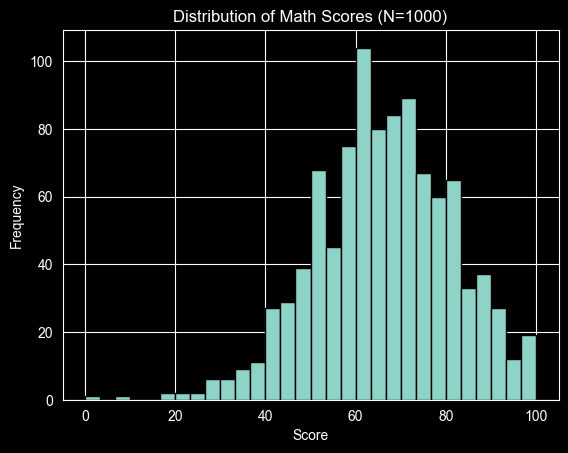

In [4]:
plt.hist(df['math score'], bins=30, edgecolor='black')
plt.title('Distribution of Math Scores (N=1000)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

So the graphic a little bit skewed to the right, otherwise we can see normal distribution


In [5]:
mean_math = df['math score'].mean()
print(f"Mean math score: {mean_math:.2f}")
variance_math = df['math score'].var()
print(f"Variance math score: {variance_math:.2f}")
std_math = df['math score'].std()
print(f"Standard deviation: {std_math:.2f}")
length = len(df['math score'])
print(f"The length: {length}")
#calculated mean to see if the mean score is differ from  65, variance and std to see how much the scores varyyy

Mean math score: 66.09
Variance math score: 229.92
Standard deviation: 15.16
The length: 1000


In [6]:
#the formula of t-test is mean value of sample minus hypothesized population mean divided by std divide into square of sample size
t_test, p_value = stats.ttest_1samp(df['math score'], 65)
print(f"The t-statistic: {t_test:.2f}")
print(f"P value: {p_value:.2f}")
alpha = 0.05
if p_value < alpha:
    print("Reject H0 - Significant difference")
else:
    print("Fail to reject H0 - Not significant")

The t-statistic: 2.27
P value: 0.02
Reject H0 - Significant difference


On average, people write statistically significantly higher than the standard of 65 (p=0.02)

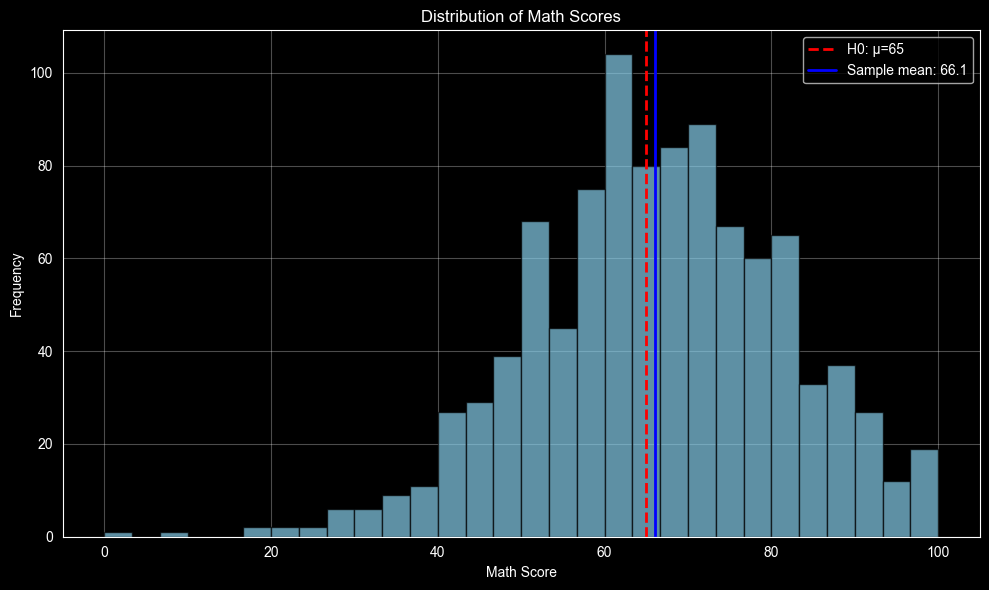

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(df['math score'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(65, color='red', linestyle='--', linewidth=2, label='H0: μ=65')
plt.axvline(mean_math, color='blue', linestyle='-', linewidth=2, label=f'Sample mean: {mean_math:.1f}')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.title('Distribution of Math Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
test_none = df[df['test preparation course'] == 'none']
test_completed = df[df['test preparation course'] == 'completed']

In [9]:
t_stat, p_value_two_tailed = stats.ttest_ind(test_completed['math score'],test_none['math score'], equal_var=False)
mean_no_prep = test_none['math score'].mean()
mean_prep = test_completed['math score'].mean()
print(f"Mean score who doesnt prepared {mean_no_prep:.2f}")
print(f"Mean score who prepared {mean_prep:.2f}")


Mean score who doesnt prepared 64.08
Mean score who prepared 69.70


In [10]:
if t_stat > 0:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1 - (p_value_two_tailed / 2)

print(f"\nWelch's t-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"Two-tailed p-value: {p_value_two_tailed:.10f}")
print(f"One-tailed p-value: {p_value_one_tailed:.10f}")

alpha = 0.05
if p_value_one_tailed < alpha:
    print(f"\n REJECT H0 (p = {p_value_one_tailed:.4f} < {alpha})")
    print("Test preparation significantly IMPROVES math scores!")
else:
    print(f"\n FAIL TO REJECT H0 (p = {p_value_one_tailed:.4f} > {alpha})")
    print("No significant evidence that preparation improves scores")


Welch's t-test results:
T-statistic: 5.7870
Two-tailed p-value: 0.0000000104
One-tailed p-value: 0.0000000052

 REJECT H0 (p = 0.0000 < 0.05)
Test preparation significantly IMPROVES math scores!


In [11]:
reading_mean = df['reading score'].mean()
writing_mean = df['writing score'].mean()
t_stat, p_value= stats.ttest_rel(df['reading score'], df['writing score'])
print(f"\nMean Reading score: {reading_mean:.2f}")
print(f"Mean Writing score: {writing_mean:.2f}")
print(f"Difference: {reading_mean - writing_mean:.2f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"Refect H0 - Significant difference")
    if reading_mean > writing_mean:
        print(f"Students read better than write")
    else:
        print(f"Students write better than read")
else:
    print(f"Fail to reject H0 - Not significant")




Mean Reading score: 69.17
Mean Writing score: 68.05
Difference: 1.11

T-statistic: 7.7874
P-value: 0.0000
Refect H0 - Significant difference
Students read better than write


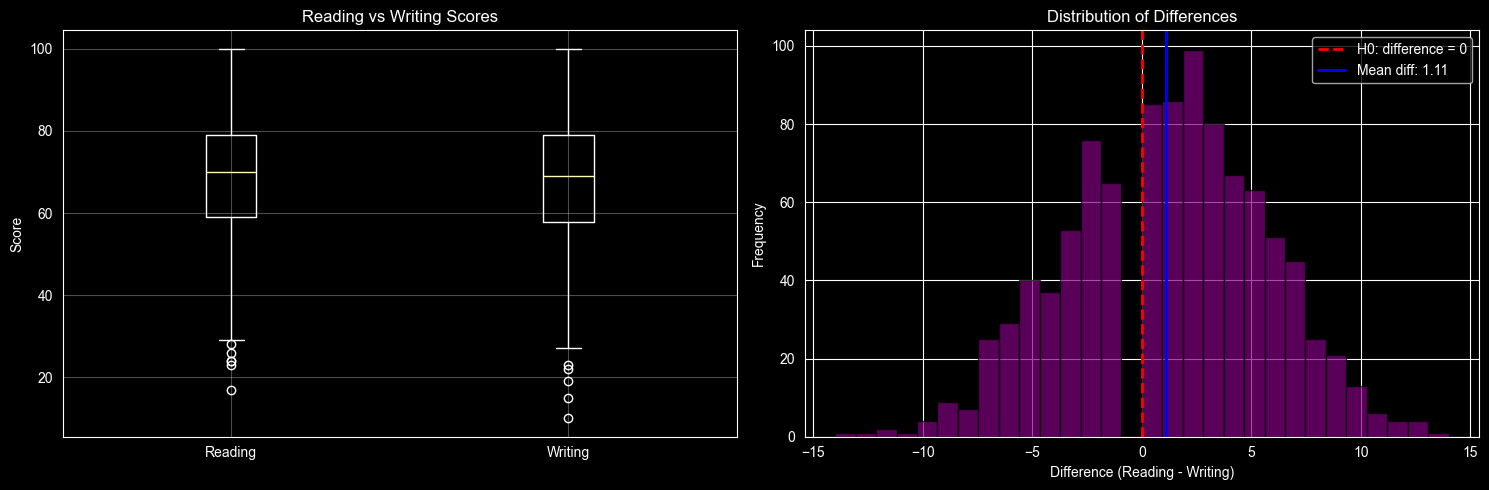

In [12]:
df['diff'] = df['reading score'] - df['writing score']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
box_data = [df['reading score'], df['writing score']]
axes[0].boxplot(box_data, tick_labels=['Reading', 'Writing'])
axes[0].set_ylabel('Score')
axes[0].set_title('Reading vs Writing Scores')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['diff'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='H0: difference = 0')
axes[1].axvline(df['diff'].mean(), color='blue', linestyle='-',
                linewidth=2, label=f'Mean diff: {df["diff"].mean():.2f}')
axes[1].set_xlabel('Difference (Reading - Writing)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Differences')
axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
df['exc'] = (df['math score'] > 80).astype(int)
male = df[df['gender'] == 'male']
female = df[df['gender'] == 'female']
exc_male = male['exc'].sum()
exc_female = female['exc'].sum()
fail_male = len(male) - exc_male
fail_female = len(female) - exc_female
p_male_exc = exc_male / len(male)
total_male = len(male)
total_female = len(female)
print(f"Total amount of male: {total_male}")
print(f"Total amount of female: {total_female}")
p_female_exc = exc_female / len(female)
print(f"number of boys with a score > 80:  {exc_male:.2f}")
print(f"Number of boys with score ≤ 80 (Failures): {fail_male}")
print(f"number of girls with a score > 80: {exc_female:.2f}")
print(f"Number of girls with score ≤ 80 (Failures): {fail_female}")
print(f"Probability of male {p_male_exc:.2f}")
print(f"Probability of female {p_female_exc:.2f}")


Total amount of male: 482
Total amount of female: 518
number of boys with a score > 80:  108.00
Number of boys with score ≤ 80 (Failures): 374
number of girls with a score > 80: 68.00
Number of girls with score ≤ 80 (Failures): 450
Probability of male 0.22
Probability of female 0.13


In [14]:
male_success_ok = exc_male >= 10
male_failure_ok = fail_male >= 10
female_success_ok = exc_female >= 10
female_failure_ok = fail_female >= 10
print(f"Males: Successes = {exc_male} (>=10? {male_success_ok})")
print(f"Males: Failures = {fail_male} (>=10? {male_failure_ok})")
print(f"Females: Successes = {exc_female} (>=10? {female_success_ok})")
print(f"Females: Failures = {fail_female} (>=10? {female_failure_ok})")

if male_success_ok and male_failure_ok and female_success_ok and female_failure_ok:
    print("All groups have at least 10 successes and 10 failures.")
    print("We can use normal approximation (z-test)")
else:
    print("At least one group has less than 10 successes or failures.")

Males: Successes = 108 (>=10? True)
Males: Failures = 374 (>=10? True)
Females: Successes = 68 (>=10? True)
Females: Failures = 450 (>=10? True)
All groups have at least 10 successes and 10 failures.
We can use normal approximation (z-test) for Question 4.


In [15]:
#pooled propotion
prop = (exc_male + exc_female) / (total_male + total_female)
print(f"Pooled Proportion: {prop:.2f}")
counts = np.array([exc_male, exc_female])
nobs = np.array([total_male,total_female])
z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

print(f"Z-statistics: {z_stat}")
print(f"P-value: {p_value}")

Pooled Proportion: 0.18
Z-statistics: 3.850172660001171
P-value: 0.00011803458667598488


In [16]:
if p_value < alpha:
    print(f" REJECT H0 (p = {p_value:.4f} < {alpha})")
    if exc_male/total_male > exc_female/total_female:
        print("Males have significantly higher excellence rate!")
    else:
        print("Females have significantly higher excellence rate")
else:
    print(f" FAIL TO REJECT H0 (p = {p_value:.4f} > {alpha})")
    print("No significant gender gap in excellence")


 REJECT H0 (p = 0.0001 < 0.05)
Males have significantly higher excellence rate!
